<a href="https://colab.research.google.com/github/BisratGetnet/Student-Score-Prediction/blob/main/Linear%20regression%20model%20%5Bonly%20study%20hours%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/StudentPerformanceFactors.csv')
display(df.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [2]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

None

In [3]:
df = df[['Hours_Studied', 'Exam_Score']]

In [4]:
display(df.describe())

,Hours_Studied,Exam_Score
count,6607.000000,6607.000000
mean,19.975329,67.235659
std,5.990594,3.890456
min,1.000000,55.000000
25%,16.000000,65.000000
50%,20.000000,67.000000
75%,24.000000,69.000000
max,44.000000,101.000000


In [5]:
df.head()

,Hours_Studied,Exam_Score
0,23,67
1,19,61
2,24,74
3,29,71
4,19,70


In [6]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Hours_Studied    0
Exam_Score       0
dtype: int64


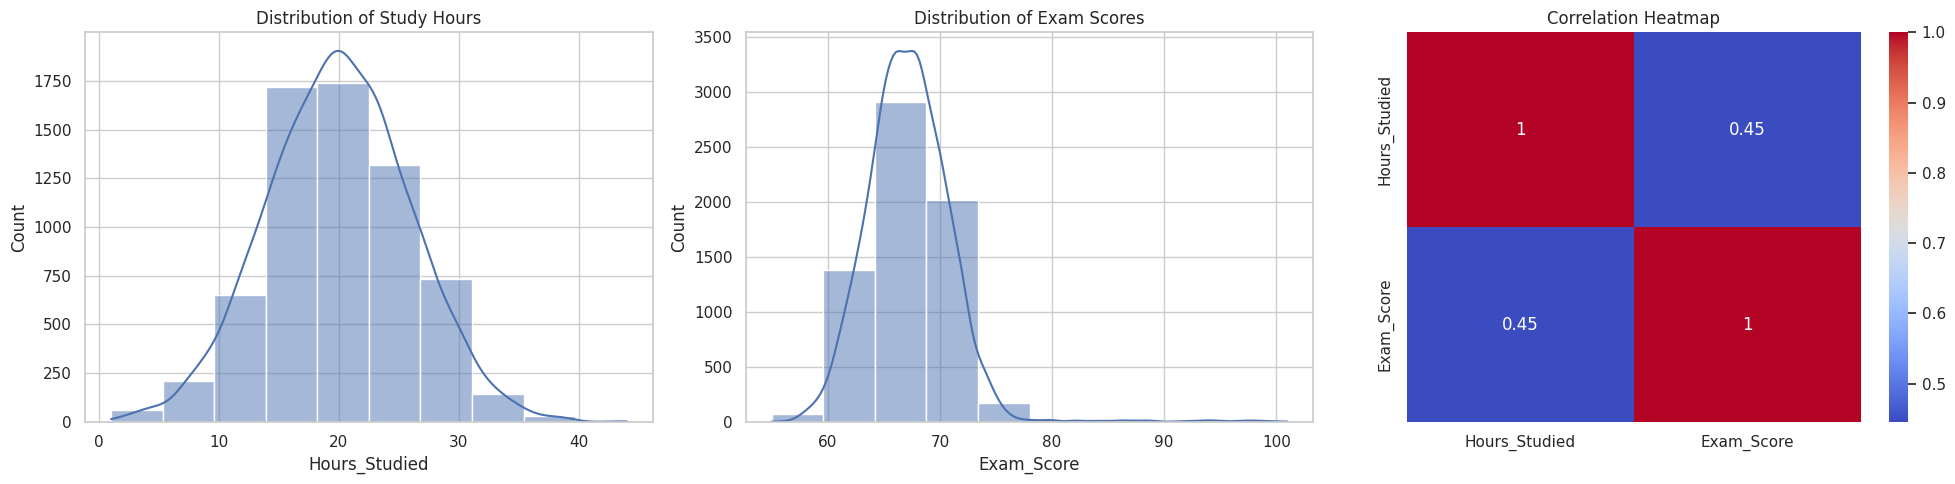

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20,5))  # 1 row, 3 columns

# Plot 1: Distribution of Hours_Studied
sns.histplot(df['Hours_Studied'], bins=10, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Study Hours")

# Plot 2: Distribution of Exam_Score
sns.histplot(df['Exam_Score'], bins=10, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Exam Scores")

# Plot 3: Correlation Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title("Correlation Heatmap")

plt.tight_layout()  # Adjust spacing
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df[['Hours_Studied']]  # Feature(s) must be in 2D
y = df['Exam_Score']       # Target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verify the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5285, 1)
X_test shape: (1322, 1)
y_train shape: (5285,)
y_test shape: (1322,)


Mean Squared Error (MSE): 10.86
R-squared (R²): 0.23


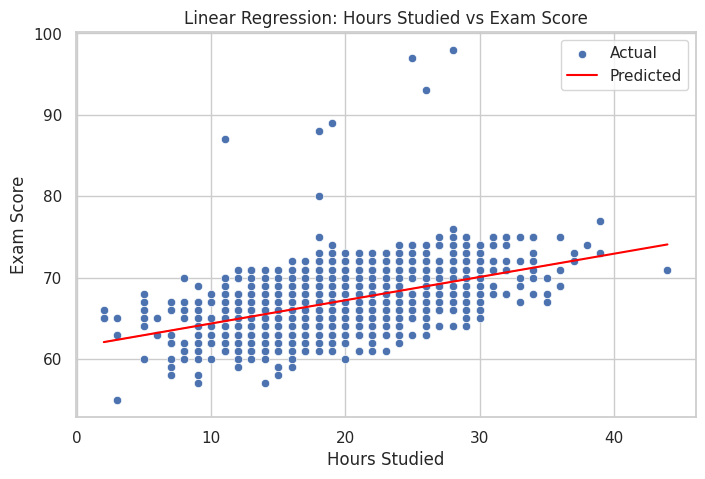

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Visualize predictions vs actual
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_test['Hours_Studied'], y=y_test, label='Actual')
sns.lineplot(x=X_test['Hours_Studied'], y=y_pred, color='red', label='Predicted')
plt.title("Linear Regression: Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.show()
